In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
######################################
from sklearnex import patch_sklearn 
patch_sklearn()
#####################################
from sklearn.metrics import precision_score, ConfusionMatrixDisplay, recall_score, accuracy_score
from sklearn.metrics import  f1_score, mean_absolute_error, auc, roc_curve, confusion_matrix
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC ,LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [2]:
df = pd.read_csv("2020/heart_2020_cleaned.csv")

FileNotFoundError: [Errno 2] No such file or directory: '2020/heart_2020_cleaned.csv'

In [3]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [5]:
df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,7.097075
std,6.356100,7.95085,7.955235,1.436007
min,12.020000,0.00000,0.000000,1.000000
25%,24.030000,0.00000,0.000000,6.000000
50%,27.340000,0.00000,0.000000,7.000000
75%,31.420000,2.00000,3.000000,8.000000
max,94.850000,30.00000,30.000000,24.000000


In [6]:
enc= LabelEncoder()
for i in df.columns:
  if df[i].dtype=='object' :
    df[i]=enc.fit_transform(df[i])
df.describe()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
count,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.00000,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000
mean,0.085595,28.325399,0.412477,0.068097,0.037740,3.37171,3.898366,0.138870,0.475273,6.514536,4.396742,0.300386,0.775362,2.220904,7.097075,0.134061,0.036833,0.093244
std,0.279766,6.356100,0.492281,0.251912,0.190567,7.95085,7.955235,0.345812,0.499389,3.564759,1.212208,0.716480,0.417344,1.534647,1.436007,0.340718,0.188352,0.290775
min,0.000000,12.020000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,24.030000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,4.000000,5.000000,0.000000,1.000000,1.000000,6.000000,0.000000,0.000000,0.000000
50%,0.000000,27.340000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,7.000000,5.000000,0.000000,1.000000,2.000000,7.000000,0.000000,0.000000,0.000000
75%,0.000000,31.420000,1.000000,0.000000,0.000000,2.00000,3.000000,0.000000,1.000000,9.000000,5.000000,0.000000,1.000000,4.000000,8.000000,0.000000,0.000000,0.000000
max,1.000000,94.850000,1.000000,1.000000,1.000000,30.00000,30.000000,1.000000,1.000000,12.000000,5.000000,3.000000,1.000000,4.000000,24.000000,1.000000,1.000000,1.000000


<Axes: >

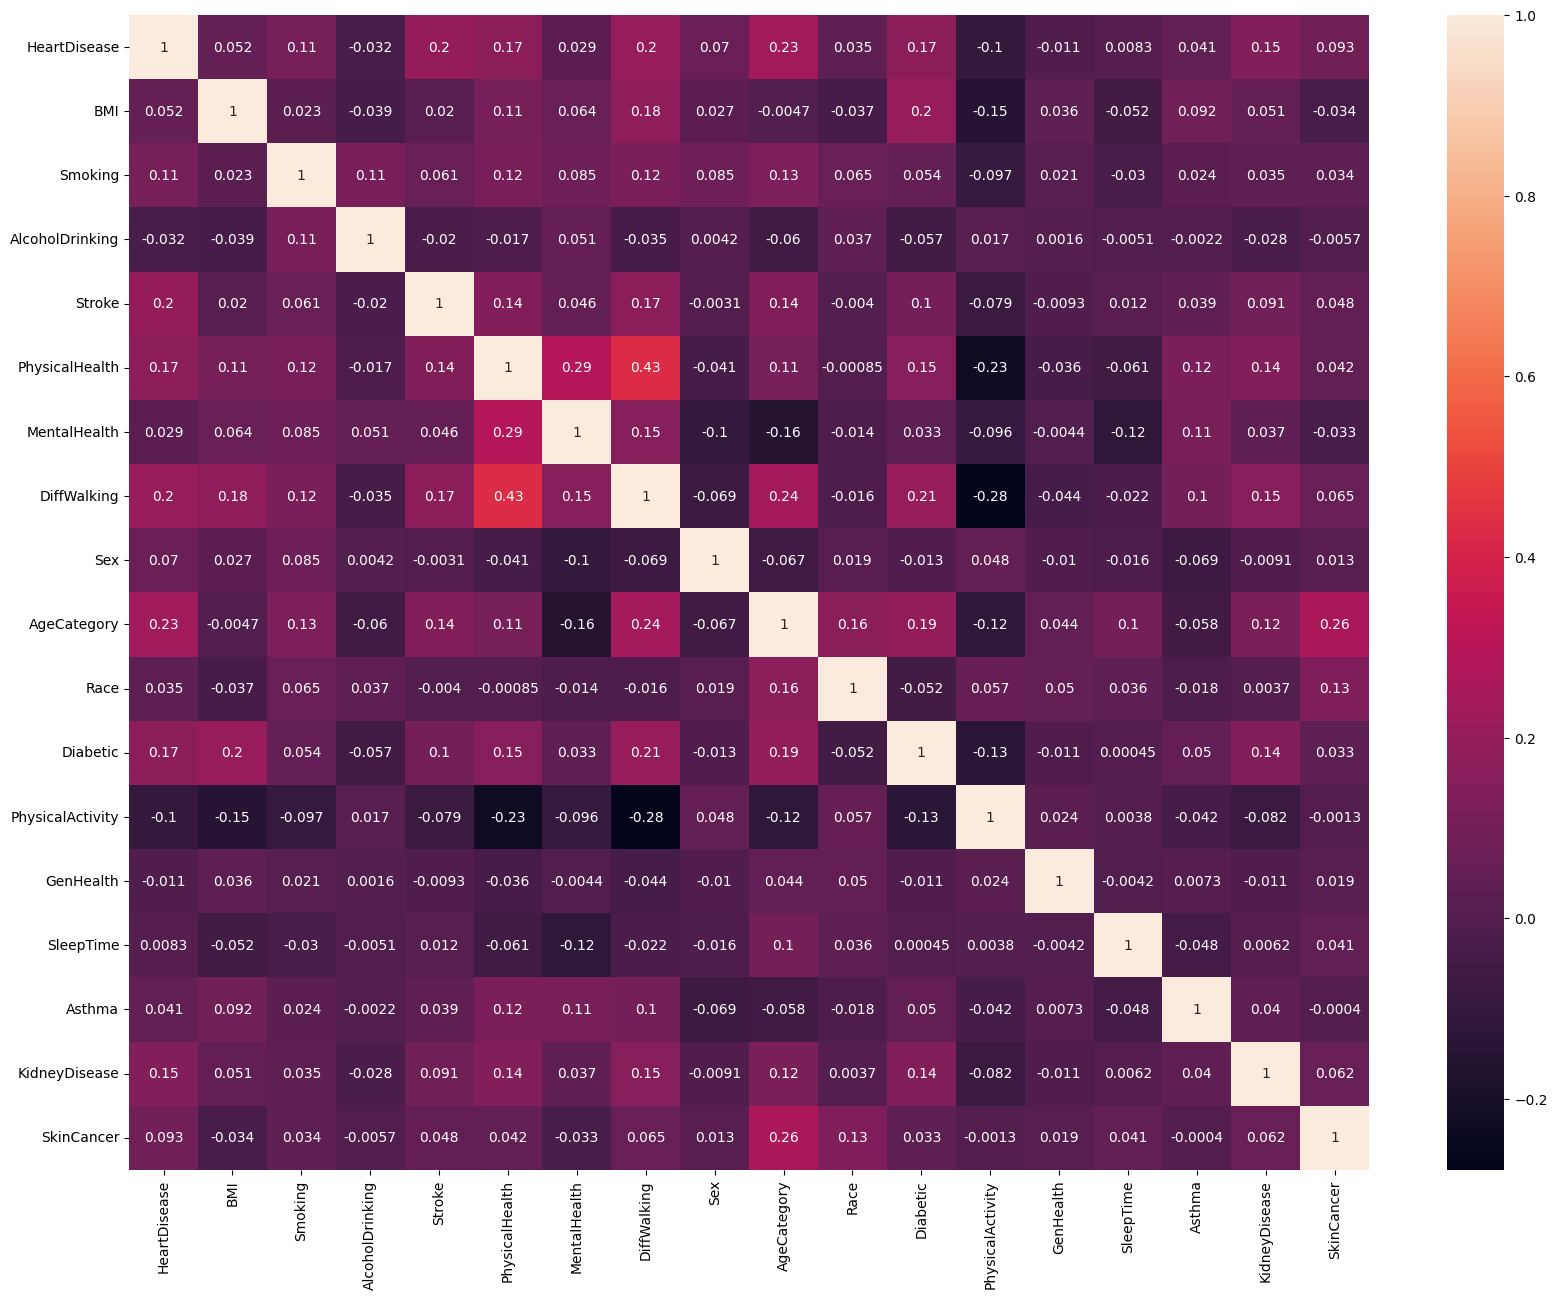

In [7]:
df_corr = df.corr()
plt.subplots(figsize=(20,15))
sns.heatmap(df_corr, annot = True)

In [8]:
# separate independent & dependent variables
X = df.iloc[:,0:14]  #independent columns
y = df.iloc[:,-1]    #target column i.e price range

# apply SelectKBest class to extract top 10 best features
bestfeatures = SelectKBest(score_func=chi2, k=10)
fit = bestfeatures.fit(X,y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)

#concat two dataframes for better visualization 
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #naming the dataframe columns
print(featureScores.nlargest(14,'Score'))  #print 10 best features

               Specs         Score
9        AgeCategory  43324.047785
5     PhysicalHealth  10425.881777
6       MentalHealth   5795.669860
0       HeartDisease   2546.422374
10              Race   1941.545317
7        DiffWalking   1157.795015
4             Stroke    712.434776
11          Diabetic    578.053408
1                BMI    516.275067
2            Smoking    216.908561
13         GenHealth    122.197093
8                Sex     30.283261
3    AlcoholDrinking      9.690660
12  PhysicalActivity      0.126656


In [9]:
featureScores = featureScores.sort_values(by='Score', ascending=False)
featureScores

,Specs,Score
9,AgeCategory,43324.047785
5,PhysicalHealth,10425.881777
6,MentalHealth,5795.669860
0,HeartDisease,2546.422374
10,Race,1941.545317
7,DiffWalking,1157.795015
4,Stroke,712.434776
11,Diabetic,578.053408
1,BMI,516.275067
2,Smoking,216.908561


In [10]:
features_list = featureScores["Specs"].tolist()[:12]
features_list

['AgeCategory',
 'PhysicalHealth',
 'MentalHealth',
 'HeartDisease',
 'Race',
 'DiffWalking',
 'Stroke',
 'Diabetic',
 'BMI',
 'Smoking',
 'GenHealth',
 'Sex']

In [11]:
df = df[['AgeCategory',
 'PhysicalHealth',
 'MentalHealth',
 'HeartDisease',
 'Race',
 'DiffWalking',
 'Stroke',
 'Diabetic',
 'BMI',
 'Smoking',
 'GenHealth',
 'Sex']]

In [12]:
scaler = MinMaxScaler(feature_range=(0,1)) 
#assign scaler to column:
filtered_data = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
filtered_data.describe()

,AgeCategory,PhysicalHealth,MentalHealth,HeartDisease,Race,DiffWalking,Stroke,Diabetic,BMI,Smoking,GenHealth,Sex
count,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000
mean,0.542878,0.112390,0.129946,0.085595,0.879348,0.138870,0.037740,0.100129,0.196854,0.412477,0.555226,0.475273
std,0.297063,0.265028,0.265175,0.279766,0.242442,0.345812,0.190567,0.238827,0.076737,0.492281,0.383662,0.499389
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.333333,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.144996,0.000000,0.250000,0.000000
50%,0.583333,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.184957,0.000000,0.500000,0.000000
75%,0.750000,0.066667,0.100000,0.000000,1.000000,0.000000,0.000000,0.000000,0.234215,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
df.HeartDisease.value_counts()

HeartDisease
0    292422
1     27373
Name: count, dtype: int64

In [14]:
# Shuffle df
shuffled_df = df.sample(frac=1,random_state=4)

# Put all the fraud class in a separate dataset.
CHD_df = shuffled_df.loc[shuffled_df['HeartDisease'] == 1]

#Randomly select 492 observations from the non-fraud (majority class)
non_CHD_df = shuffled_df.loc[shuffled_df['HeartDisease'] == 0].sample(n=28000,random_state=42)

# Concatenate both dataframes again
normalized_df = pd.concat([CHD_df, non_CHD_df])

# check new class counts
normalized_df.HeartDisease.value_counts()


HeartDisease
0    28000
1    27373
Name: count, dtype: int64

In [15]:
P = normalized_df.HeartDisease
X = normalized_df.drop(['HeartDisease'], axis = 1)
x_train, x_test, y_train, y_test = train_test_split(X,P, test_size = 0.25, random_state = 42)


In [16]:
result_table = pd.DataFrame(columns=['classifiers', 'fpr','tpr','auc'])
y = y_test.values

Confusion Matrix (Testing Data):


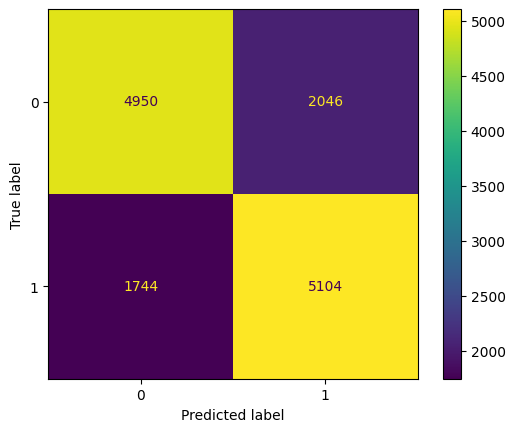

Accuracy Test :  72.62351921409997
Precision Score:  71.38461538461539
Recall Score :  74.53271028037383
F1 score :  72.92470352907559
Mean absolute error : 27.376480785900032
AUC score :  72.64371363075296


C:\Users\Hp\AppData\Local\Temp\ipykernel_14920\3879925632.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"RandomForestClassifier",


In [17]:
#Random Forest Classifier 
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
test_res = rf.predict(x_test)


#Confusion Matrix 
confusion_matrix_test = confusion_matrix(y_test, test_res)

print("Confusion Matrix (Testing Data):")
obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###

fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)

##################################################


yproba = rf.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"RandomForestClassifier",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)


Confusion Matrix (Testing Data):


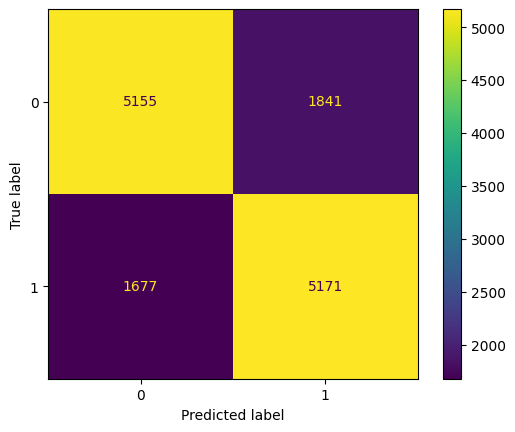

Accuracy Test :  74.58826928633343
Precision Score:  73.74500855675984
Recall Score :  75.51109813084112
F1 score :  74.61760461760461
Mean absolute error : 25.411730713666568
AUC score :  74.59803048337368


In [18]:
#Logistic Regression Classifier 
lr = LogisticRegression(max_iter = 1000)
lr.fit(x_train, y_train)
test_res = lr.predict(x_test)


#Confusion Matrix 
confusion_matrix_test = confusion_matrix(y_test, test_res)

print("Confusion Matrix (Testing Data):")
obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###

fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)

######################################

yproba = lr.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"LogisticRegression",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)

Confusion Matrix (Testing Data):


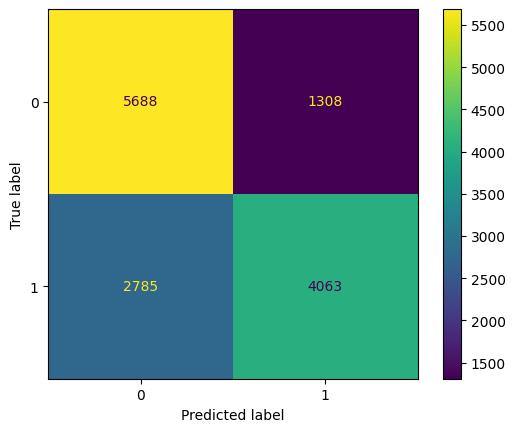

Accuracy Test :  70.43484542039873
Precision Score:  75.64699311115248
Recall Score :  59.331191588785046
F1 score :  66.50298715115804
Mean absolute error : 29.56515457960127
AUC score :  70.31739682355203


In [19]:
#Naive Bayes 
gnb = GaussianNB()
gnb.fit(x_train, y_train)

test_res = gnb.predict(x_test)

#Confusion Matrix 
confusion_matrix_test = confusion_matrix(y_test, test_res)

print("Confusion Matrix (Testing Data):")
obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###

fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)


##########################################

yproba = gnb.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"NaiveBayes",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)

Confusion Matrix (Testing Data):


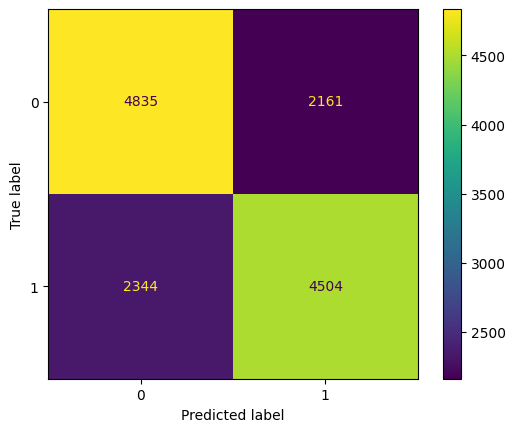

Accuracy Test :  67.45882692863334
Precision Score:  67.5768942235559
Recall Score :  65.77102803738318
F1 score :  66.66173314585954
Mean absolute error : 32.54117307136666
AUC score :  67.44097428169901


In [20]:
#Decision Tree Classsifier 

dtc = DecisionTreeClassifier()
dtc.fit(x_train, y_train)
test_res = dtc.predict(x_test)

#Confussion Matrix 
confusion_matrix_test = confusion_matrix(y_test, test_res)

print("Confusion Matrix (Testing Data):")
obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###

fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)

##############################################

yproba = dtc.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"DecisionTreeClassifier",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)

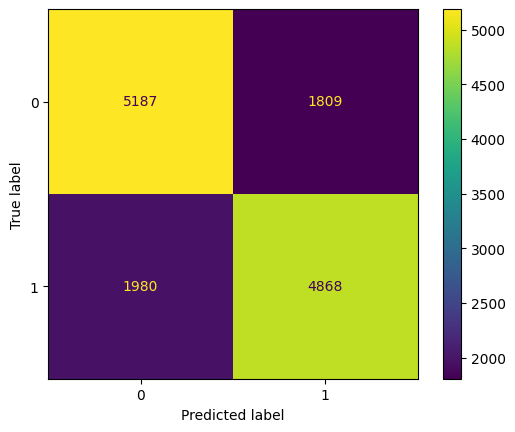

Accuracy Test :  72.63074255995377
Precision Score:  72.90699415905347
Recall Score :  71.08644859813083
F1 score :  71.98521256931609
Mean absolute error : 27.36925744004623
AUC score :  72.6144078325131


In [21]:
#KN Classifier 
kn = KNeighborsClassifier(n_neighbors = 10)
kn.fit(x_train, y_train)

test_res = kn.predict(x_test)

#Confusion Matrix 

confusion_matrix_test = confusion_matrix(y_test, test_res)

obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)
###
fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)

#######################################

yproba = kn.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"KNeighborsClassifier",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)

Confusion Matrix (Testing Data):


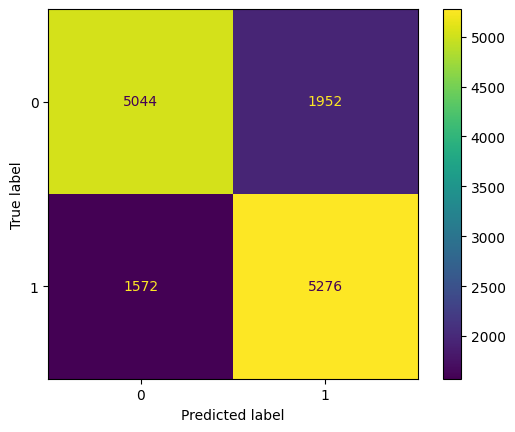

Accuracy Test :  74.54492921121063
Precision Score:  72.99391256225789
Recall Score :  77.0443925233645
F1 score :  74.9644785450412
Mean absolute error : 25.45507078878937
AUC score :  74.57136721651358


In [22]:
#Simple Vector Classifier 
svc = SVC(kernel = 'linear', probability = True)
svc.fit(x_train, y_train)

test_res = svc.predict(x_test)

#Confusion Matrix 
confusion_matrix_test = confusion_matrix(y_test, test_res)

print("Confusion Matrix (Testing Data):")

obj = ConfusionMatrixDisplay(confusion_matrix_test)
obj.plot()
plt.show()

print("Accuracy Test : ", accuracy_score(y_test,test_res)*100)
print("Precision Score: ", precision_score(y_test, test_res)*100)
print("Recall Score : ", recall_score(y_test, test_res)*100)
print("F1 score : ", f1_score(y_test, test_res)*100)
print("Mean absolute error :", mean_absolute_error(y_test, test_res)*100)

fpr, tpr, thresholds  = roc_curve(y_test,test_res)
AUC = metrics.auc(fpr,tpr)
print("AUC score : ", AUC*100)


In [23]:

yproba = svc.predict_proba(x_test)
    
fpr, tpr, _ = roc_curve(y,  yproba[:,1])
auc = roc_auc_score(y, yproba[:,1])
result_table = pd.concat([result_table, pd.DataFrame([{'classifiers':"SVC",
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}])], ignore_index=True)

In [24]:
result_table.set_index('classifiers', inplace=True)

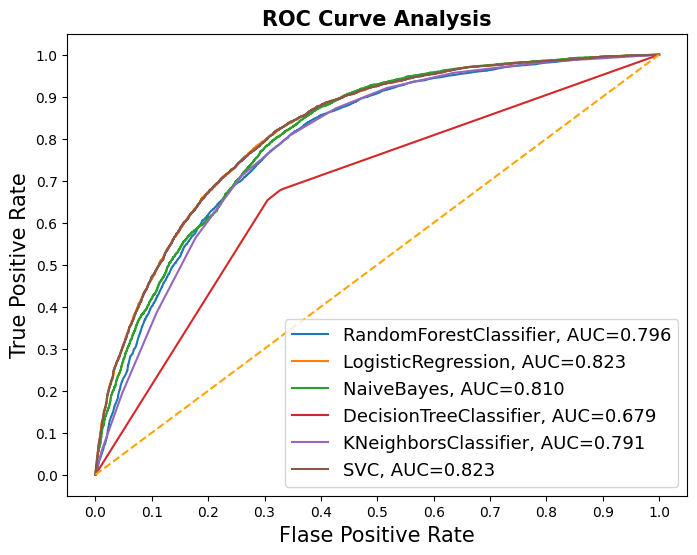

In [25]:
fig = plt.figure(figsize=(8,6))

for i in result_table.index:
    plt.plot(result_table.loc[i]['fpr'], 
             result_table.loc[i]['tpr'], 
             label="{}, AUC={:.3f}".format(i, result_table.loc[i]['auc']))
    
plt.plot([0,1], [0,1], color='orange', linestyle='--')

plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("Flase Positive Rate", fontsize=15)

plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.ylabel("True Positive Rate", fontsize=15)

plt.title('ROC Curve Analysis', fontweight='bold', fontsize=15)
plt.legend(prop={'size':13}, loc='lower right')

plt.show()